# Question 9: Food Price Spikes and Economic Anxiety in Germany

## Research Question
To what extent are increases in food prices associated with economic concerns expressed in online public discourse in Germany?

## Data Sources

This analysis combines three types of data:

- **Eurostat Consumer Price Index (CPI)** data for selected food products (butter, dairy products, and margarine) in Germany.
- **Google Trends** data capturing public search interest related to food prices.
- **YouTube comments** discussing food inflation in Germany.

The goal is to explore whether rising food prices are associated with increased public attention and expressions of economic anxiety.

## Use of AI Tools

ChatGPT was used to support the development of this notebook. This includes assistance in refining the structure of the analysis, improving selected helper functions (e.g. JSON-to-DataFrame conversion and time-series preprocessing), and suggesting suitable visualization approaches. 

All code and results were reviewed, adapted where necessary, and validated independently.

In [1]:
# Define file paths for all datasets used in the notebook.
import json
from pathlib import Path
import numpy as np
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt



DATA_DIR = Path(".")

BUTTER_FILE = DATA_DIR / "eurostat_butter_cpi.json"
DAIRY_FILE = DATA_DIR / "eurostat_cpi_dairy.json"
MARGARINE_FILE = DATA_DIR / "margarine_cpi.json"
TRENDS_FILE = DATA_DIR / "google_trends/trends_bundle.json"
YOUTUBE_COMMENTS_FILE = DATA_DIR / "youtube_food_inflation_comments_germany.json"

In [2]:
def load_eurostat_json(file_path: Path, value_name: str) -> pd.DataFrame:
    """Load Eurostat JSON data and convert it into a tidy DataFrame."""
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    values = data["value"]
    time_index = data["dimension"]["time"]["category"]["index"]
    
    # Build row-wise records by matching each time label to its numeric value.
    rows = []
    for date_str, idx in time_index.items():
        value = values.get(str(idx))
        if value is not None:
            rows.append({
                "date": pd.to_datetime(date_str),
                value_name: float(value)
            })
    
    # Return a DataFrame sorted by date for time-series analysis.
    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df

In [3]:
# Load and merge the three consumer price index series into one dataset.
butter_df = load_eurostat_json(BUTTER_FILE, "butter_price")
dairy_df = load_eurostat_json(DAIRY_FILE, "dairy_price")
margarine_df = load_eurostat_json(MARGARINE_FILE, "margarine_price")

price_df = (
    butter_df
    .merge(dairy_df, on="date", how="outer")
    .merge(margarine_df, on="date", how="outer")
    .sort_values("date")
    .reset_index(drop=True)
)
# Calculate monthly percentage changes for each price series.
for col in ["butter_price", "dairy_price", "margarine_price"]:
    price_df[f"{col}_pct_change"] = price_df[col].pct_change()

In [4]:
def load_trends_json(file_path: Path, key: str, value_name: str) -> pd.DataFrame:
    """Load Google Trends JSON data and return a cleaned date-value DataFrame."""
    with open(file_path, "r", encoding="utf-8") as f:
        trends = json.load(f)
    
    trend_data = trends["files"][key]["data"]
    df = pd.DataFrame(trend_data).copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.rename(columns={"value": value_name})
    # Some Google Trends exports store values as single-item lists.
    if isinstance(df[value_name].iloc[0], list):
        df[value_name] = df[value_name].str[0]
    # Convert trend values to numeric format and coerce invalid entries to missing values.
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df[["date", value_name]].sort_values("date").reset_index(drop=True)

In [5]:
price_df.head()

,date,butter_price,dairy_price,margarine_price,butter_price_pct_change,dairy_price_pct_change,margarine_price_pct_change
0,1996-01-01,NaN,79.9,NaN,NaN,NaN,NaN
1,1996-02-01,NaN,79.9,NaN,NaN,0.000000,NaN
2,1996-03-01,NaN,80.0,NaN,NaN,0.001252,NaN
3,1996-04-01,NaN,80.1,NaN,NaN,0.001250,NaN
4,1996-05-01,NaN,79.9,NaN,NaN,-0.002497,NaN


In [6]:
# Load Google search interest data for butter-related queries.
trends_df = load_trends_json(
    TRENDS_FILE,
    key="iot_Butter.json",
    value_name="butter_search_interest"
)

In [7]:
# Aggregate both datasets to monthly frequency and merge them on a shared year-month key.
price_monthly = price_df.copy()
price_monthly["year_month"] = price_monthly["date"].dt.to_period("M")

trends_monthly = trends_df.copy()
trends_monthly["year_month"] = trends_monthly["date"].dt.to_period("M")
# Average search interest within each month to align it with monthly price data.
trends_monthly = (
    trends_monthly
    .groupby("year_month", as_index=False)["butter_search_interest"]
    .mean()
)

merged_df = price_monthly.merge(
    trends_monthly,
    on="year_month",
    how="inner"
)

In [8]:
print(merged_df.shape)
merged_df.head()

(61, 9)


,date,butter_price,dairy_price,margarine_price,butter_price_pct_change,dairy_price_pct_change,margarine_price_pct_change,year_month,butter_search_interest
0,2019-12-01,144.3,110.5,108.2,-0.012320,-0.002708,-0.027853,2019-12,36.0
1,2020-01-01,144.9,110.9,110.9,0.004158,0.003620,0.024954,2020-01,32.0
2,2020-02-01,143.3,110.9,110.8,-0.011042,0.000000,-0.000902,2020-02,30.5
3,2020-03-01,142.7,111.1,110.6,-0.004187,0.001803,-0.001805,2020-03,31.8
4,2020-04-01,142.5,111.6,111.2,-0.001402,0.004500,0.005425,2020-04,40.0


In [9]:
# Compare the relationship between butter prices and public search interest.
analysis_df = merged_df.copy()

analysis_df["butter_price_change"] = analysis_df["butter_price"].pct_change()
analysis_df["search_interest_change"] = analysis_df["butter_search_interest"].pct_change()
# Measure correlations for both raw levels and month-to-month changes.
level_corr = analysis_df["butter_price"].corr(analysis_df["butter_search_interest"])
change_corr = analysis_df["butter_price_change"].corr(analysis_df["search_interest_change"])

print("Level correlation:", round(level_corr, 3))
print("Change correlation:", round(change_corr, 3))

Level correlation: 0.681
Change correlation: 0.172


In [10]:
# Smooth both series with a 3-month rolling mean to reduce short-term noise.
analysis_df["butter_price_smooth"] = analysis_df["butter_price"].rolling(3).mean()
analysis_df["search_interest_smooth"] = analysis_df["butter_search_interest"].rolling(3).mean()

smooth_corr = analysis_df["butter_price_smooth"].corr(analysis_df["search_interest_smooth"])

print("Smoothed correlation (3-month rolling mean):", round(smooth_corr, 3))

Smoothed correlation (3-month rolling mean): 0.734


In [11]:
# Test whether earlier butter prices are associated with later search interest.

lag_results = {}
# Shift butter prices by 1 to 3 months and compute the corresponding correlations.
for lag in [1, 2, 3]:
    merged_df[f"butter_price_lag_{lag}"] = merged_df["butter_price"].shift(lag)
    corr = merged_df[f"butter_price_lag_{lag}"].corr(merged_df["butter_search_interest"])
    lag_results[lag] = corr

lag_df = pd.DataFrame({
    "lag_months": list(lag_results.keys()),
    "correlation": list(lag_results.values())
})

lag_df

,lag_months,correlation
0,1,0.657617
1,2,0.628197
2,3,0.587762


People may react with a delay to rising butter prices.

In [12]:
# Load YouTube comments for the qualitative analysis.
with open(YOUTUBE_COMMENTS_FILE, "r", encoding="utf-8") as f:
    comments = json.load(f)
# Store comments in a DataFrame for text-based analysis.
comments_df = pd.DataFrame(comments, columns=["comment"])

In [13]:

# Define a keyword-based measure of economic concern in German-language comments.
FEAR_WORDS = [
    "teuer", "inflation", "krise", "arm", "preise",
    "unbezahlbar", "existenz", "rezession", "sorgen",
    "geld", "wirtschaft", "angst", "schulden",
    "pleite", "kosten", "lebenshaltung", "energie",
    "miete", "sparsam", "armut", "belastung"
]

def tokenize_german_text(text: str) -> list[str]:
    """Tokenize German text into lowercase word tokens while preserving umlauts and ß."""  
    text = str(text).lower()
    # Extract alphabetic tokens and ignore punctuation or numbers.
    return re.findall(r"\b[a-zäöüß]+\b", text)

def fear_score(text: str, fear_words: list[str] = FEAR_WORDS) -> int:
    """Count how many predefined concern-related terms appear in a comment."""  
    tokens = tokenize_german_text(text)
    # Use a set so each keyword is counted at most once per comment.
    token_set = set(tokens)
    return sum(word in token_set for word in fear_words)

In [14]:
# Apply the keyword-based concern score to all comments.
comments_df["fear_score"] = comments_df["comment"].apply(fear_score)
comments_df["fear_present"] = comments_df["fear_score"] > 0
# Calculate the share of comments that contain at least one concern-related term.
fear_share = comments_df["fear_present"].mean()

print("Share of comments containing economic concern:", round(fear_share,3))

Share of comments containing economic concern: 0.292


In [15]:
# Summarize how many comments contain concern-related terms.
fear_counts = comments_df["fear_present"].value_counts()

print("Comments with economic concern terms:", fear_counts.get(True, 0))
print("Comments without such terms:", fear_counts.get(False, 0))
print("Share of concern-related comments:", round(comments_df["fear_present"].mean(), 3))

Comments with economic concern terms: 158
Comments without such terms: 383
Share of concern-related comments: 0.292


In [16]:
discourse_summary = {
    "mean_fear_score": comments_df["fear_score"].mean(),
    "total_fear": comments_df["fear_score"].sum(),
    "n_comments": comments_df["comment"].count(),
    "share_fear_comments": comments_df["fear_present"].mean()
}

discourse_summary

{'mean_fear_score': np.float64(0.3752310536044362),
 'total_fear': np.int64(203),
 'n_comments': np.int64(541),
 'share_fear_comments': np.float64(0.2920517560073937)}

In [17]:
# Prepare a cleaned corpus for word-frequency analysis.
stopwords = {
    "die","der","das","und","ist","ich","du","er","sie","es","wir","ihr",
    "nicht","ein","eine","einer","einem","einen","den","dem","des",
    "zu","mit","für","auf","von","an","im","in","am","auch","so",
    "man","aber","noch","wie","wenn","dass","da","dann","mehr",
    "mal","nur","schon","hier","ja","nein","halt","eben",
    "sind","war","waren","wird","werden","haben","hat","hatte",
    "bei","alles","oder","als","sich","immer","wobei","jedoch",
    "aktuell","zb","zbsp","jahr",
    "was","kann","keine","muss","wieder","gibt","machen","viel",
    "zum","weniger","kein","durch","wer","uns","alle"
}
# Combine all comments into one lowercase text string.
all_text = " ".join(comments_df["comment"].astype(str)).lower()
# Remove punctuation and non-letter characters.
all_text = re.sub(r"[^a-zäöüß\s]", " ", all_text)
# Exclude stopwords and very short tokens to focus on meaningful terms.
clean_words = [
    word for word in all_text.split()
    if word not in stopwords and len(word) > 2
]
# Exclude stopwords and very short tokens to focus on meaningful terms.
word_freq = Counter(clean_words)
top_words = word_freq.most_common(15)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

## Interpretation

A considerable proportion of the YouTube comments contains language associated with economic concern. About 42% of all comments include at least one keyword related to prices, inflation, money, or financial hardship. In addition, the average fear score of approximately 0.59 indicates that economic concerns appear regularly across the discussion. Overall, these findings suggest that online conversations about food prices are closely linked to issues of affordability and perceived economic pressure.

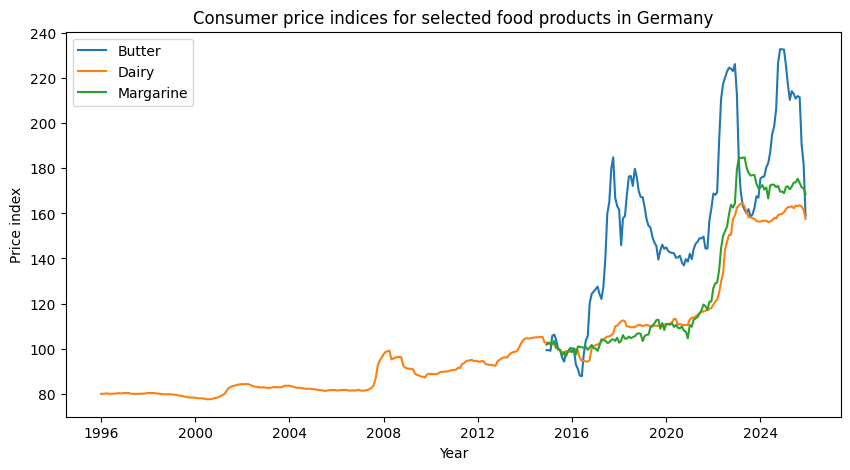

In [18]:
# Plot the consumer price indices of butter, dairy products, and margarine over time.
plt.figure(figsize=(10,5))

plt.plot(price_df["date"], price_df["butter_price"], label="Butter")
plt.plot(price_df["date"], price_df["dairy_price"], label="Dairy")
plt.plot(price_df["date"], price_df["margarine_price"], label="Margarine")

plt.legend()
plt.title("Consumer price indices for selected food products in Germany")
plt.xlabel("Year")
plt.ylabel("Price index")

plt.show()

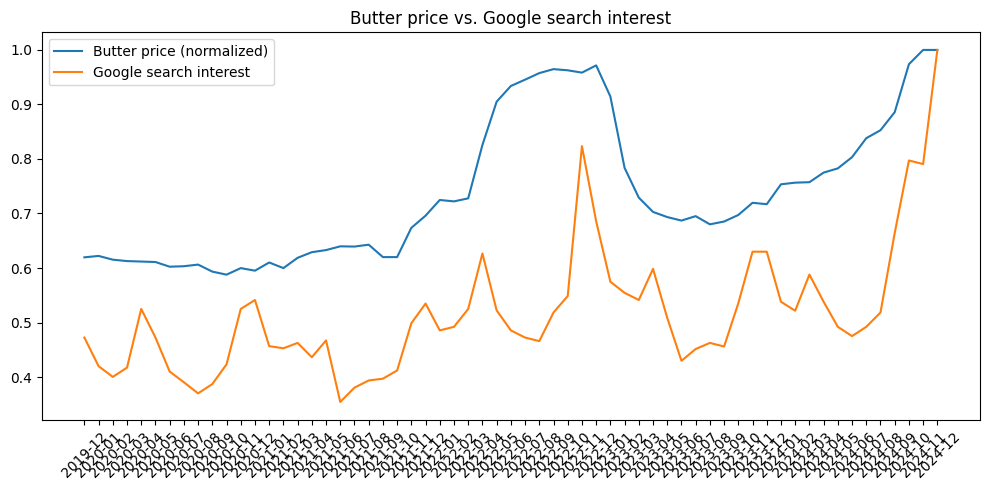

In [19]:
# Normalize both series to compare their relative development on the same scale.
plt.figure(figsize=(10,5))

butter_norm = merged_df["butter_price"] / merged_df["butter_price"].max()
search_norm = merged_df["butter_search_interest"] / merged_df["butter_search_interest"].max()

plt.plot(merged_df["year_month"].astype(str), butter_norm, label="Butter price (normalized)")
plt.plot(merged_df["year_month"].astype(str), search_norm, label="Google search interest")

plt.xticks(rotation=45)
plt.legend()
plt.title("Butter price vs. Google search interest")

plt.tight_layout()
plt.show()

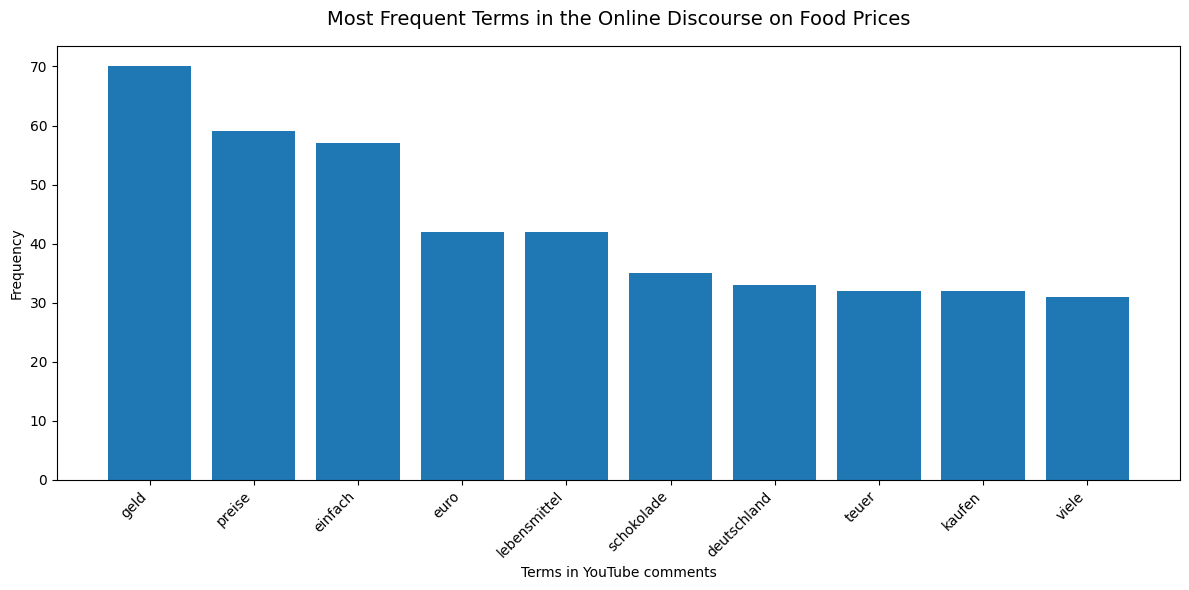

In [20]:
# Select the most frequent words for visualization.
top_words = word_freq.most_common(10)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.title(
    "Most Frequent Terms in the Online Discourse on Food Prices",
    fontsize=14,
    pad=15
)

plt.xlabel("Terms in YouTube comments")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [21]:
# csv vorbereiten für website 

# =========================
# 1. PRICE DATA
# =========================

price_export = price_df[["date", "butter_price", "dairy_price", "margarine_price"]].copy()

price_export["type"] = "price_indices"
price_export["year_month"] = pd.NA
price_export["butter_search_interest"] = pd.NA
price_export["fear_score"] = pd.NA
price_export["count"] = pd.NA

price_export = price_export[
    [
        "type",
        "date",
        "year_month",
        "butter_price",
        "dairy_price",
        "margarine_price",
        "butter_search_interest",
        "fear_score",
        "count",
    ]
]


# =========================
# 2. PRICE VS SEARCH DATA
# =========================

price_search_export = merged_df[["year_month", "butter_price", "butter_search_interest"]].copy()

price_search_export["year_month"] = price_search_export["year_month"].astype(str)
price_search_export["type"] = "price_vs_search"
price_search_export["date"] = pd.NaT
price_search_export["dairy_price"] = pd.NA
price_search_export["margarine_price"] = pd.NA
price_search_export["fear_score"] = pd.NA
price_search_export["count"] = pd.NA

price_search_export = price_search_export[
    [
        "type",
        "date",
        "year_month",
        "butter_price",
        "dairy_price",
        "margarine_price",
        "butter_search_interest",
        "fear_score",
        "count",
    ]
]


# =========================
# 3. ECONOMIC CONCERN DATA
# =========================

fear_distribution_export = (
    comments_df["fear_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fear_distribution_export.columns = ["fear_score", "count"]

fear_distribution_export["type"] = "economic_concern"
fear_distribution_export["date"] = pd.NaT
fear_distribution_export["year_month"] = pd.NA
fear_distribution_export["butter_price"] = pd.NA
fear_distribution_export["dairy_price"] = pd.NA
fear_distribution_export["margarine_price"] = pd.NA
fear_distribution_export["butter_search_interest"] = pd.NA

fear_distribution_export = fear_distribution_export[
    [
        "type",
        "date",
        "year_month",
        "butter_price",
        "dairy_price",
        "margarine_price",
        "butter_search_interest",
        "fear_score",
        "count",
    ]
]


# =========================
# 4. CONCATENATE
# =========================

rq9_export_df = pd.concat(
    [price_export, price_search_export, fear_distribution_export],
    ignore_index=True
)

# anschauen
rq9_export_df.head()
rq9_export_df.to_csv("../../website/data/rq9_data.csv", index=False)

/var/folders/kw/zc7qtxtd0j5dyfl27njttk200000gn/T/ipykernel_74718/743280433.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rq9_export_df = pd.concat(
